# Description

Prove that the Noise Reduction model works on a 2D polinomial.

Add libs folder path to system variables in order to make the importation of local libraries easier.

In [ ]:
import os
import sys

CURRENT_DIR = os.getcwd()
FOLDERS = CURRENT_DIR.split(os.sep)
TESIS_FOLDER_INDEX = FOLDERS.index('S-noise-gradient')
CURRENT_DIR = os.sep.join(FOLDERS[:TESIS_FOLDER_INDEX+1])
LIBS_PATH = os.path.join(CURRENT_DIR, 'src', 'libs')
assert os.path.exists(LIBS_PATH)
sys.path.append(LIBS_PATH)

Import external and local libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import display
from tqdm import tqdm
import math
from typing import List

# Locals
from utils import *
from dataset import Dataset
from models import *
import config as cfg
from dlnr import DLNoiseReduction

Global / Path variables

In [ ]:
DATA_PATH = os.path.join(CURRENT_DIR, 'data')
CHECKPOINT_PATH = os.path.join(CURRENT_DIR, 'checkpoints')
CONFIG_PATH = os.path.join(CURRENT_DIR, 'config')

Make sure that the GPU is being used

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert device.type == "cuda"

Functions definition

In [ ]:
def polinomial_function(x:float):
    """
    Function that takes in a value x and returns its polinomial value.

    Args:
        x (float): value to be transformed.

    Returns:
        float: result of the polinomial function.
    """

    return x**4 -x**3 -20*(x**2) -20*x +6


def add_gaussian_noise(df:pd.DataFrame, columns:List[str], mean:float = 0.0, std:float = 0.1):
    """
    Adds Gaussian noise to specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The DataFrame to which noise will be added.
        columns (list): A list of column names in the DataFrame to which noise will be added.
        mean (int, optional): The mean of the Gaussian distribution. Defaults to 0.
        std (float, optional): The standard deviation of the Gaussian distribution. Defaults to 0.1.

    Returns:
        pandas.DataFrame: The DataFrame with added Gaussian noise to specified columns.
    """
    for col in columns:
        df[col] = df[col] + np.random.normal(loc=mean, scale=std, size=len(df))
    return df

Generate 2D data with normal distribution at the points indicated in ‘means’ variable.  
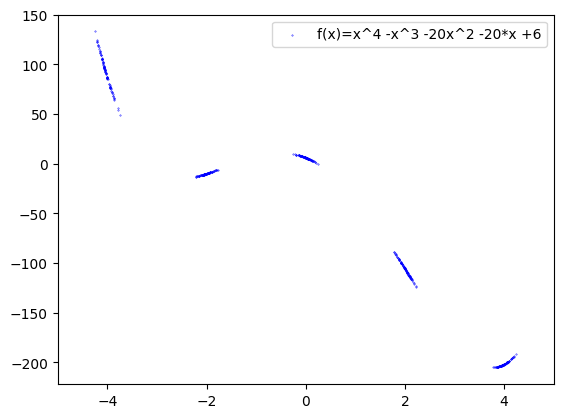

In [ ]:
means = [-4, -2, 0, 2, 4]
X_train = [np.random.normal(loc=m, scale=0.1, size=(100)) for m in means]
X_train = np.concatenate(X_train, axis=0)
y_train = polinomial_function(X_train)

df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Generate continious 2D data like so  
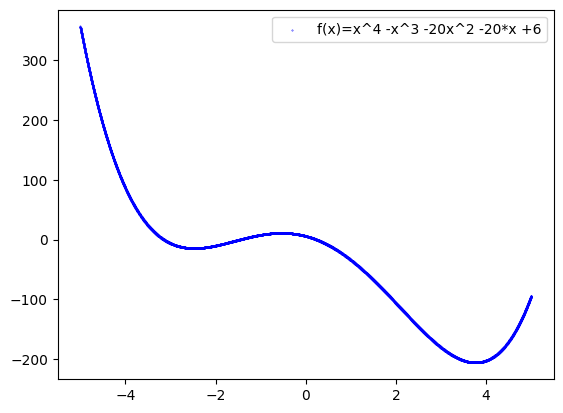

In [ ]:
X_train = np.linspace(-5, 5, 10001)
y_train = polinomial_function(X_train)

df_train = pd.DataFrame({'X': X_train, 'y': y_train})

Copy the dataframe into validation, test and noisy dataframes

In [ ]:
df_val = df_train.copy()
df_test = df_train.copy()
df_noisy = df_train.copy()

Scale the noisy dataframe into [0,1] domain

In [ ]:
scaler = MinMaxScaler()
df_noisy = pd.DataFrame(scaler.fit_transform(df_noisy))
df_noisy.columns = ['X', 'y']

Add goussian noise to the dataframe

In [ ]:
sigma = 0.02
df_noisy = add_gaussian_noise(
        df=df_noisy.copy(),
        columns=[x for x in df_train.columns],
        mean=0,
        std=sigma
)

Plot the new noisy data

In [ ]:
plt.title('Data with noise')
plt.scatter(df_noisy['X'], df_noisy['y'], color='r', s=0.1)

Scale the others dataframe

In [ ]:
df_train = pd.DataFrame(scaler.transform(df_train), columns=['X', 'y'])
df_val = pd.DataFrame(scaler.transform(df_val), columns=['X', 'y'])
df_test = pd.DataFrame(scaler.transform(df_test), columns=['X', 'y'])

Create Datasets for DataLoaders

In [ ]:
# Transform the data into a tensor
bio_dataset_train = Dataset(
    input_df=df_noisy[['X']],
    target_df=df_noisy[['y']]
)
# Transform the data into a tensor
bio_dataset_val = Dataset(
    input_df=df_val[['X']],
    target_df=df_val[['y']]
)

# Create the dataloaders
batch_size = 64
train_dataloader = DataLoader(bio_dataset_train, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = DataLoader(bio_dataset_val, batch_size=batch_size, shuffle=True, num_workers=0)

Create Neural Network model

In [ ]:
model = GridFullyDenseNN(
    n_layers=2,
    hidden_layers=[
        (1, 1024),
        (1024, 1),
    ],
    dropout_layers=[
        0.0,
        0.0,
    ],
    activation_func_layers=[
        nn.ReLU(),
        nn.Identity(),
    ],
    want_dropout=[
        False,
        False,
    ],
    want_linear=[
        True,
        True,
    ],
    want_activation=[
        True,
        False,
    ],
)
model.to(device)

Set model parameters and create the model Trainer object

In [ ]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Define the trainer
trainer_basic = Trainer(
    model=model,
    train_generator=train_dataloader,
    val_generator=val_dataloader,
    device=device,
    criterion=criterion,
    optimizer=optimizer,
    epoch_scheduler=None,
    batch_scheduler=None,
    patience=15,
    epochs=500,
    checkpoints_path=os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial')
)

Train the model

In [ ]:
model, train_losses, val_losses, best_train_loss, best_val_loss = trainer_basic.fit(verbose=True)

or load a checkpoint

In [ ]:
# model.load_state_dict(torch.load(os.path.join(CHECKPOINT_PATH, f'model_noise_{sigma}_polinomial.pth')))

Predict over the datasets

In [ ]:
y_pred_test = model(torch.tensor(df_test['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [ ]:
y_pred_val = model(torch.tensor(df_val['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [ ]:
y_pred_train = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

In [ ]:
y_pred_noisy = model(torch.tensor(df_noisy['X'].values.reshape(-1, 1)).float().to(device)).cpu().detach().numpy().reshape(-1)

Show the metrics

In [ ]:
gt_values = df_test['y'].values
predicted_values = y_pred_test

In [ ]:
mae = mean_absolute_error(gt_values, predicted_values)
mse = mean_squared_error(gt_values, predicted_values)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(gt_values - predicted_values) / gt_values) * 100
r_squared = r2_score(gt_values, predicted_values)
print("MAE: ", mae)
print("MAPE: ", mape)
print("MSE: ", mse)
print("RMSE: ", rmse)
print("R-squared: ", r_squared)

In [ ]:
plt.scatter(df_noisy['X'].values, df_noisy['y'].values, color='b', label='True train', s=5, alpha=0.02)
# plt.scatter(df_noisy['X'].values, y_pred_train, color='cyan', label='Pred train', s=5, alpha=0.02)
# plt.scatter(df_val['X'].values, y_pred_val, color='pink', label='Pred val', s=5, alpha=0.02)
plt.scatter(df_test['X'].values, y_pred_test, color='lime', label='Predicción', s=5, alpha=0.02)
plt.legend()
plt.show()

# Gradients to reduce noise

In [ ]:
df_no_noise = df_noisy.copy()
dlnr = DLNoiseReduction(model=model, criterion=criterion)
dlnr.fit(df_noisy['X'].values.reshape(-1, 1), df_noisy['y'].values.reshape(-1, 1))

In [ ]:
df_no_noise['X'], df_no_noise['y'] = dlnr.transform(
                                                nrr=0.05,
                                                nr_threshold=0.01,
                                                max_epochs=100,
                                                plot_progress=True
)

In [ ]:
dlnr.assert_improvement(
    x_denoised = df_no_noise['X'].values.reshape(-1, 1),
    y_denoised = df_no_noise['y'].values.reshape(-1, 1),
    x_orig = df_train['X'].values.reshape(-1, 1),
    y_orig = df_train['y'].values.reshape(-1, 1)
)